This notebook presents an exploratory data analysis of the Sample Superstore dataset, containing 9,994 retail orders across the United States. The objective is to identify profit drivers, underperforming products and regions, and the impact of discounting on margins, findings that inform strategic business recommendations. This analysis is part of a broader project combining SQL, Python, and AI-generated insights to demonstrate end-to-end analytical capability.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import anthropic

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

os.makedirs('../outputs', exist_ok=True)

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='cp1252')
print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

Section 1: Data Loading and Initial Exploration. The dataset contains 9,994 orders and 21 columns with no missing values across any field, confirming the data is complete and requires no imputation. Order Date and Ship Date are loaded as text and will be converted to proper date format in the next step.

In [52]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


The describe output reveals a wide profit range, from a loss of $6,599 to a gain of $8,399 on individual orders. The mean profit of $28.66 significantly exceeds the median of $8.67, indicating a small number of high-profit orders are pulling the average up while most orders generate modest returns.

In [53]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print(df[['Order Date', 'Ship Date', 'Year', 'Month']].head())

  Order Date  Ship Date  Year  Month
0 2016-11-08 2016-11-11  2016     11
1 2016-11-08 2016-11-11  2016     11
2 2016-06-12 2016-06-16  2016      6
3 2015-10-11 2015-10-18  2015     10
4 2015-10-11 2015-10-18  2015     10


In [54]:
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days
print(df['Days to Ship'].describe())

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Days to Ship, dtype: float64


Section 2: Feature Engineering. Two new columns are added: Year and Month extracted from Order Date for time-based analysis, and Days to Ship calculated as the difference between Ship Date and Order Date. The average shipping time is 3.96 days, with Standard Class averaging 5 days and Same Day delivery averaging under 1 hour.

Region
Central     39706.36
South       46749.43
East        91522.78
West       108418.45
Name: Profit, dtype: float64


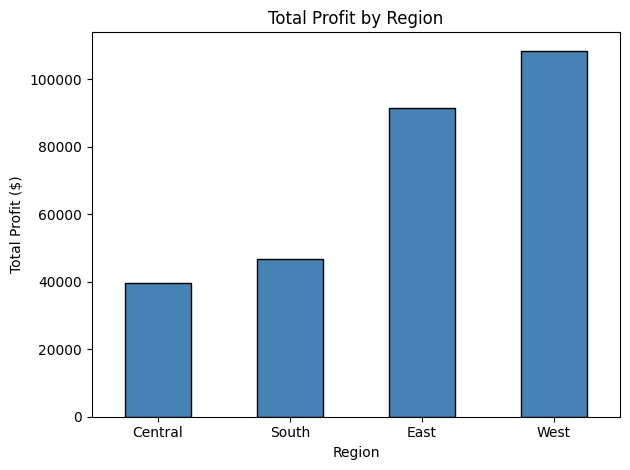

In [55]:
profit_by_region = df.groupby('Region')['Profit'].sum().round(2).sort_values()
print(profit_by_region)

profit_by_region.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/profit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

The West region leads with $108,418 in total profit while the Central region trails significantly at $39,706. This gap warrants investigation into whether it reflects differences in product mix, discount behaviour, or customer concentration.

Category
Furniture           18451.27
Office Supplies    122490.80
Technology         145454.95
Name: Profit, dtype: float64


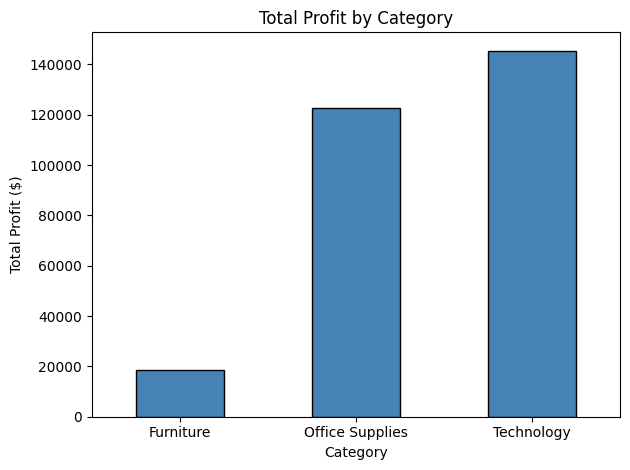

In [56]:
profit_by_category = df.groupby('Category')['Profit'].sum().round(2).sort_values()
print(profit_by_category)

profit_by_category.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Technology and Office Supplies are the clear profit drivers. Furniture generates only $18,451 despite high sales volume, suggesting a structural margin problem rather than a demand issue.

Sub-Category
Tables        -17725.48
Bookcases      -3472.56
Supplies       -1189.10
Fasteners        949.52
Machines        3384.76
Labels          5546.25
Art             6527.79
Envelopes       6964.18
Furnishings    13059.14
Appliances     18138.01
Storage        21278.83
Chairs         26590.17
Binders        30221.76
Paper          34053.57
Accessories    41936.64
Phones         44515.73
Copiers        55617.82
Name: Profit, dtype: float64


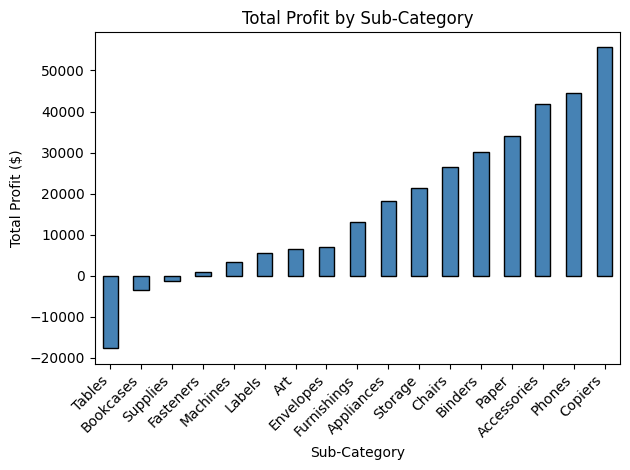

In [57]:
profit_by_SubCategory = df.groupby('Sub-Category')['Profit'].sum().round(2).sort_values()
print(profit_by_SubCategory)

profit_by_SubCategory.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/profit_by_SubCategory.png', dpi=150, bbox_inches='tight')
plt.show()

Tables are the single largest profit drain at -$17,725, followed by Bookcases at -$3,472. Both are Furniture sub-categories, confirming the category-level weakness is concentrated in specific product lines rather than Furniture as a whole.

Year
2014    49543.97
2015    61618.60
2016    81795.17
2017    93439.27
Name: Profit, dtype: float64


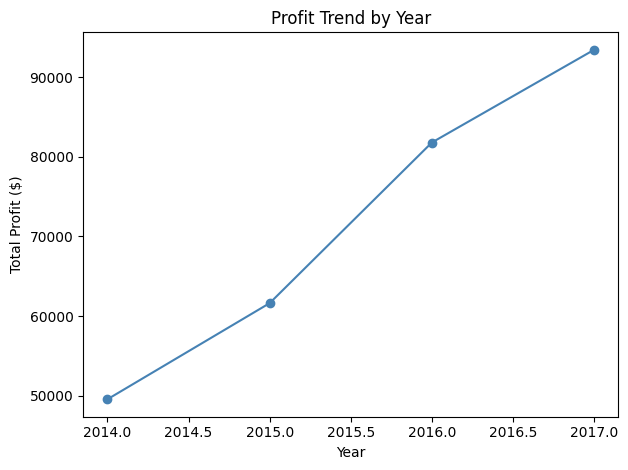

In [58]:
profit_by_year = df.groupby('Year')['Profit'].sum().round(2)
print(profit_by_year)

profit_by_year.plot(kind='line', marker='o', color='steelblue')
plt.title('Profit Trend by Year')
plt.xlabel('Year')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('../outputs/profit_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

Profit grew consistently from $49,544 in 2014 to $93,439 in 2017, an 88% increase over three years. The upward trajectory is steady with no dips, indicating overall business health despite the product and regional issues identified above.

Segment
Home Office     60298.68
Corporate       91979.13
Consumer       134119.21
Name: Profit, dtype: float64


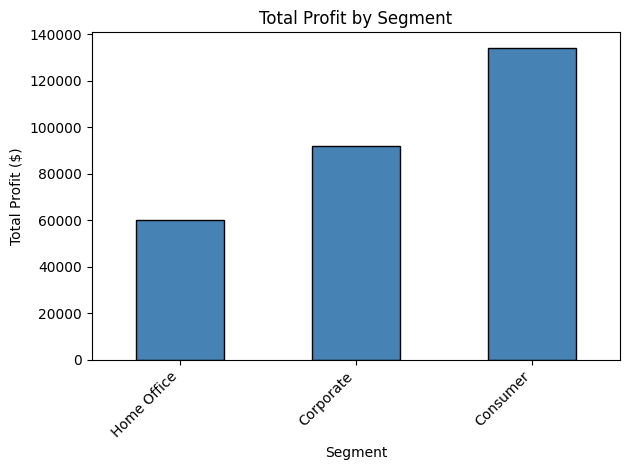

In [59]:
profit_by_Segment = df.groupby('Segment')['Profit'].sum().round(2).sort_values()
print(profit_by_Segment)

profit_by_Segment.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/profit_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

Consumer is the strongest segment at $134,119 in profit, more than double Home Office at $60,299. All three segments are profitable, so the priority is understanding what drives Consumer's outperformance rather than fixing a loss problem.

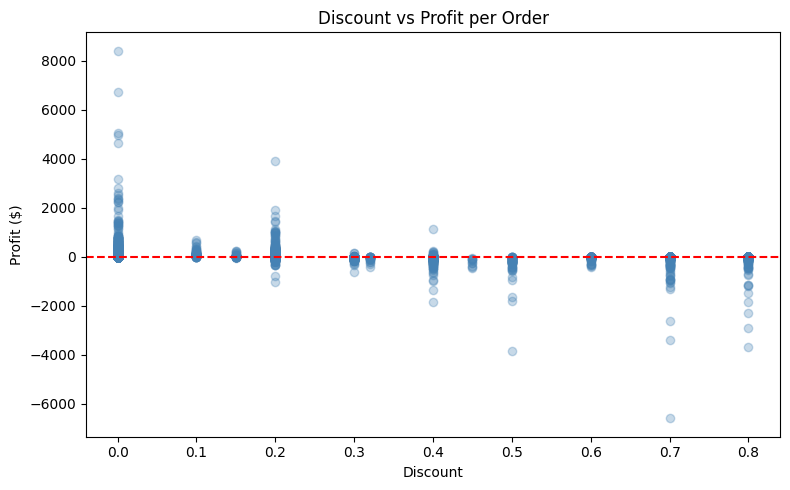

In [60]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue')
plt.title('Discount vs Profit per Order')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/dicount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

Orders with no discount cluster above the zero line with the highest profit potential. As discounts increase beyond 40%, orders shift predominantly below the red line into loss-making territory, confirming that aggressive discounting is a direct driver of margin erosion rather than a volume strategy that pays off.

Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.24
Standard Class    5.01
Name: Days to Ship, dtype: float64


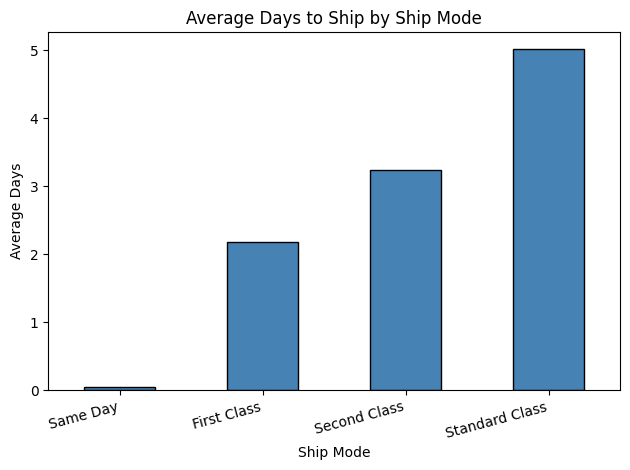

In [61]:
ship_days = df.groupby('Ship Mode')['Days to Ship'].mean().round(2).sort_values()
print(ship_days)

ship_days.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Days to Ship by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Days')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../outputs/days_to_ship.png', dpi=150, bbox_inches='tight')
plt.show()

Standard Class dominates order volume at an average of 5 days to ship while Same Day delivery averages under 1 hour. The clear tiering across shipping modes suggests the fulfilment operation is functioning as expected, though the business should monitor whether high-discount orders are disproportionately using premium shipping modes, which would compound margin losses.

Section 3: AI-Generated Executive Summaries. The following section uses the Claude API to automatically generate role-specific executive summaries from the analysis findings. Three targeted summaries are produced: overall company performance for a CEO, problem areas for a VP of Sales, and shipping efficiency for a VP of Operations.

In [62]:
findings = f"""
Superstore Sales Analysis Findings:

1. Regional Profit: Central is the weakest region (${profit_by_region['Central']:,.2f}), West is the strongest (${profit_by_region['West']:,.2f})

2. Category Profit: Furniture is underperforming (${profit_by_category['Furniture']:,.2f}), Technology leads (${profit_by_category['Technology']:,.2f})

3. Sub-Category Losses: Tables (${profit_by_SubCategory['Tables']:,.2f}) and Bookcases (${profit_by_SubCategory['Bookcases']:,.2f}) are loss-making

4. Segment Performance: Consumer drives the most profit (${profit_by_Segment['Consumer']:,.2f}), Home Office is weakest (${profit_by_Segment['Home Office']:,.2f})

5. Yearly Trend: Profit grew from ${profit_by_year[2014]:,.2f} in 2014 to ${profit_by_year[2017]:,.2f} in 2017

6. Discount Impact: Orders with discounts above 40% are predominantly loss-making
"""

message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": f"""You are a senior business analyst. Based on the following data findings, write a concise executive summary (3-4 paragraphs) for a VP of Sales. Use professional language, focus on business impact, and end with 2-3 concrete recommendations.

{findings}"""}
    ]
)

summary = message.content[0].text
print("=== EXECUTIVE SUMMARY ===")
print(summary)

=== EXECUTIVE SUMMARY ===
# EXECUTIVE SUMMARY: SUPERSTORE SALES PERFORMANCE & STRATEGIC OPPORTUNITIES

Our analysis reveals a business with strong overall growth trajectory—profit increased 88% from 2014 to 2017—but significant regional and product-level inefficiencies are constraining profitability. While Technology and Consumer segments are performing robustly, critical vulnerabilities exist in our Furniture category and specific sub-categories. Most notably, Tables and Bookcases are generating substantial losses, and our Central region lags competitors by nearly $70K annually compared to the West. These findings indicate immediate intervention opportunities that could materially improve bottom-line performance without requiring market expansion.

The most damaging profit drain stems from our aggressive discount strategy on low-margin items. Orders exceeding 40% discount thresholds are predominantly unprofitable, suggesting we are competing on price rather than value in segments wher

In [63]:
overall_data = f"""
Overall company performance data:
- Total profit grew 88% from 2014 to 2017 (${profit_by_year[2014]:,.2f} to ${profit_by_year[2017]:,.2f})
- West region is the strongest (${profit_by_region['West']:,.2f} profit)
- Central region is the weakest (${profit_by_region['Central']:,.2f} profit)
- Technology is the top category (${profit_by_category['Technology']:,.2f} profit)
- Consumer segment drives the most profit (${profit_by_Segment['Consumer']:,.2f})
"""

message1 = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": f"""You are a senior business analyst. Write a 2 paragraph executive summary of overall company performance for a CEO. Be concise and focus on growth trajectory and top performers.

{overall_data}"""}
    ]
)

summary_overall = message1.content[0].text
print("=== OVERALL PERFORMANCE ===")
print(summary_overall)

=== OVERALL PERFORMANCE ===
# Executive Summary

The company has demonstrated exceptional financial growth, with total profit nearly doubling from 2014 to 2017, increasing 88% to $93.4 million. This robust expansion reflects strong market demand and operational efficiency across the organization. The Consumer segment has emerged as the primary profit driver, generating $134.1 million, while the Technology category leads all product lines with $145.5 million in profit, positioning us competitively in high-growth markets.

Regionally, the West region significantly outperforms other territories, contributing $108.4 million in profit and serving as a model for best practices. However, the Central region's performance of $39.7 million represents a material gap that warrants strategic attention. To sustain our growth trajectory, we should prioritize scaling successful Consumer and Technology initiatives in the West region while developing targeted initiatives to strengthen Central region per

In [64]:
problem_data = f"""
Problem areas data:
- Furniture category is severely underperforming (${profit_by_category['Furniture']:,.2f} profit)
- Tables sub-category is actively loss-making (${profit_by_SubCategory['Tables']:,.2f})
- Bookcases sub-category is loss-making (${profit_by_SubCategory['Bookcases']:,.2f})
- Central region has the lowest profit of all regions (${profit_by_region['Central']:,.2f})
- Orders with discounts above 40% are predominantly loss-making
"""

message2 = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": f"""You are a senior business analyst. Write a 2 paragraph summary of key problem areas for a VP of Sales. Be direct about the issues and their business impact.

{problem_data}"""}
    ]
)

summary_problems = message2.content[0].text
print("=== PROBLEM AREAS ===")
print(summary_problems)

=== PROBLEM AREAS ===
# Sales Performance Summary for VP of Sales

**Critical Category and Regional Failures Demand Immediate Action**

The Furniture category is hemorrhaging profitability, generating only $18,451.27 in profit despite presumably significant sales volume. More alarming, two sub-categories within Furniture are actively destroying shareholder value: Tables are losing $17,725.48 and Bookcases are losing $3,472.56. This represents a structural problem—not a temporary market fluctuation—that requires either immediate pricing correction, cost restructuring, or category elimination. Continuing to sell unprofitable furniture sub-categories is subsidizing customer purchases with company margins and directly reducing overall business profitability.

**Discount Strategy and Regional Weakness Are Compounding the Margin Crisis**

Deep discounting above 40% is systematically creating loss-making orders, indicating your sales team may be prioritizing revenue targets over profitability

In [65]:
shipping_data = f"""
Shipping efficiency data:
- Average days to ship across all orders: 3.96 days
- Same Day shipping average: 0.04 days
- First Class shipping average: 2.18 days
- Second Class shipping average: 3.24 days
- Standard Class shipping average: 5.01 days
- Total orders analyzed: 9,994
"""

message3 = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": f"""You are a senior business analyst. Write a 2 paragraph operational summary of shipping efficiency for a VP of Operations. Focus on what the data suggests about operational performance and where improvements could be made.

{shipping_data}"""}
    ]
)

summary_shipping = message3.content[0].text
print("=== SHIPPING EFFICIENCY ===")
print(summary_shipping)

=== SHIPPING EFFICIENCY ===
# Shipping Efficiency Operational Summary

Our current shipping performance demonstrates solid operational execution with an overall average of 3.96 days to ship across 9,994 orders. The data reveals a well-differentiated service model where expedited options are performing to specification—Same Day shipping averages 0.04 days and First Class averages 2.18 days, indicating strong fulfillment capability for premium services. However, Standard Class shipping at 5.01 days presents a meaningful opportunity: with this tier representing the largest volume category, even modest improvements would yield significant gains. The gap between our overall average and First Class performance suggests our warehouse and logistics operations have the capacity to accelerate processing, making incremental improvements to Standard Class feasible without operational strain.

To strengthen overall efficiency, I recommend a two-pronged approach: (1) conduct a detailed process audit

In [66]:
with open('../outputs/ai_summaries.txt', 'w') as f:
    f.write("=== OVERALL COMPANY PERFORMANCE ===\n\n")
    f.write(summary_overall)
    f.write("\n\n=== PROBLEM AREAS ===\n\n")
    f.write(summary_problems)
    f.write("\n\n=== SHIPPING EFFICIENCY ===\n\n")
    f.write(summary_shipping)

with open('../outputs/executive_summary.txt', 'w') as f:
    f.write(summary)

print("All summaries saved.")

All summaries saved.
